# Explore from first principles daily reforecast of financial time series group question

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from get_today import get_today
get_today()

20250716

In [3]:
from get_market_pulse_25q3_questions import get_market_pulse_25q3_questions
ifps = get_market_pulse_25q3_questions()

200


In [4]:
import json
if 0:
    from get_underlying_urls import get_underlying_urls
    results = get_underlying_urls(ifps)
    with open('results.json', 'w') as f:
        json.dump(results, f, indent=4)
else:
    with open('results.json', 'r') as f:
        results = json.load(f)

In [5]:
from urls_to_ticker import urls_to_ticker
from pprint import pprint

In [ ]:
pprint(ifps[-1])

In [37]:
for ifp in ifps:
    print(ifp['title'])

What will be the maximum intraday value of the VIX over the following biweekly periods in Q3, 2025? (July 21 - Aug 1)
What will be the ending value of the ICE BofA US High Yield Option-Adjusted Spread for the following biweekly periods? (Jul 21 - Aug 1)
How much will Nvidia's stock price returns exceed Apple's in the following biweekly periods of Q3 2025? (Jul 21 - Aug 1)
How much will Nvidia's stock price returns exceed Microsoft's in the following biweekly periods of Q3 2025? (Jul 21 - Aug 1)
How much will Crude Oil Futures total price returns exceed S&P 500 Futures's in the following biweekly periods of Q3 2025? (Jul 21 - Aug 1)
How much will Nasdaq-100 Futures total price returns exceed S&P 500 Futures's in the following biweekly periods of Q3 2025? (Jul 21 - Aug 1)
How much will Gold Futures total price returns exceed S&P 500 Futures's in the following biweekly periods of Q3 2025? (Jul 21 - Aug 1)
What will be the ending value of the UST 10Y Yield for the following biweekly period

In [72]:
sources = []
for key, (title, urls) in results.items():
    print(title)
    sources.extend(urls_to_ticker(urls))
    pprint(urls)

What will be the maximum intraday value of the VIX over the following biweekly periods in Q3, 2025?
['https://en.wikipedia.org/wiki/VIX',
 'https://www.tradingview.com/symbols/CBOE-VIX/',
 'https://www.cboe.com/tradable_products/vix/vix_historical_data/']
What will be the ending value of the ICE BofA US High Yield Option-Adjusted Spread for the following biweekly periods?
['https://fred.stlouisfed.org/series/BAMLH0A0HYM2']
How much will Nvidia's stock price returns exceed Apple's in the following biweekly periods of Q3 2025?
['https://companiesmarketcap.com/',
 'https://finance.yahoo.com/quote/NVDA/history/',
 'https://finance.yahoo.com/quote/AAPL/history/']
How much will Nvidia's stock price returns exceed Microsoft's in the following biweekly periods of Q3 2025?
['https://companiesmarketcap.com/',
 'https://finance.yahoo.com/quote/NVDA/history/',
 'https://finance.yahoo.com/quote/MSFT/history/']
How much will Crude Oil Futures total price returns exceed S&P 500 Futures's in the follo

In [11]:
sources = list(sorted(set(sources)))

In [69]:
from get_yahoo_past_year import get_yahoo_past_year

In [70]:
get_yahoo_past_year('ES%3DF').head(3)

/home/catskills/Desktop/q2ai/metac-bot-template/get_yahoo_past_year.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,ES%3DF,ES%3DF,ES%3DF,ES%3DF,ES%3DF
Date,,,,,
2024-07-16,5717.25,5721.25,5673.00,5688.75,1485113
2024-07-17,5639.00,5717.75,5631.75,5715.00,2059862
2024-07-18,5594.50,5664.00,5570.25,5644.00,2528379


In [57]:
from get_revenue import get_revenue
revenue = get_revenue('AAPL')
revenue

2024-03-31    9.075300e+10
2024-06-30    8.577700e+10
2024-09-30    9.493000e+10
2024-12-31    1.243000e+11
2025-03-31    9.535900e+10
Name: Total Revenue, dtype: float64

In [58]:
from get_diluted_eps import get_diluted_eps
diluted_eps = get_diluted_eps('AAPL')
diluted_eps

2024-03-31    1.53
2024-06-30    1.40
2024-09-30    0.97
2024-12-31    2.40
2025-03-31    1.65
Name: Diluted EPS, dtype: float64

In [59]:
from forecast_next_quarter_measure import forecast_next_quarter_measure

In [60]:
forecast_next_quarter_measure(revenue)

{'Naive': 95359000000.0,
 'Average': 98223800000.0,
 'Drift': 96510500000.0,
 'Linear Regression': 112544300000.0,
 'Median': 97367150000.0}

In [61]:
forecast_next_quarter_measure(diluted_eps)

{'Naive': 1.65,
 'Average': 1.5899999999999999,
 'Drift': 1.68,
 'Linear Regression': 1.962,
 'Median': 1.665}

In [82]:
from get_fred_data import get_fred_data

In [83]:
yields = get_fred_data('BAMLH0A0HYM2')

In [84]:
yields

2024-07-16    3.08
2024-07-17    3.09
2024-07-18    3.09
2024-07-19    3.09
2024-07-22    3.05
              ... 
2025-07-09    2.94
2025-07-10    2.92
2025-07-11    2.97
2025-07-14    2.95
2025-07-15    2.95
Length: 264, dtype: float64

In [85]:
sources

[('yahoo', '^VIX', 'price'),
 ('stlouisfed', 'BAMLH0A0HYM2', 'series'),
 ('yahoo', 'NVDA', 'price'),
 ('yahoo', 'AAPL', 'price'),
 ('yahoo', 'NVDA', 'price'),
 ('yahoo', 'MSFT', 'price'),
 ('yahoo', 'CL%3DF', 'price'),
 ('yahoo', 'ES%3DF', 'price'),
 ('yahoo', 'NQ%3DF', 'price'),
 ('yahoo', 'ES%3DF', 'price'),
 ('yahoo', 'GC%3DF', 'price'),
 ('yahoo', 'ES%3DF', 'price'),
 ('stlouisfed', 'DGS10', 'series'),
 ('macrotrends', 'AAPL', 'eps-earnings-per-share-diluted'),
 ('macrotrends', 'AMD', 'eps-earnings-per-share-diluted'),
 ('macrotrends', 'AMZN', 'eps-earnings-per-share-diluted'),
 ('macrotrends', 'META', 'eps-earnings-per-share-diluted'),
 ('macrotrends', 'MSFT', 'eps-earnings-per-share-diluted'),
 ('macrotrends', 'NVDA', 'eps-earnings-per-share-diluted'),
 ('macrotrends', 'TSLA', 'eps-earnings-per-share-diluted'),
 ('macrotrends', 'AAPL', 'revenue'),
 ('macrotrends', 'AMD', 'revenue'),
 ('macrotrends', 'AMZN', 'revenue'),
 ('macrotrends', 'META', 'revenue'),
 ('macrotrends', 'MSFT',

In [196]:
def get_data_for(source, ticker, observation):
    if source == 'yahoo':
        return get_yahoo_past_year(ticker, 10)
    elif source == 'stlouisfed':
        return get_fred_data(ticker)
    elif source == 'macrotrends':
        if observation == 'eps-earnings-per-share-diluted':
            return get_diluted_eps(ticker)
        elif observation == 'revenue':
            return get_revenue(ticker)
    raise Exception("unknown combo " + str((source, ticker, observation)))

In [197]:
history = {(x,y,z): get_data_for(x,y,z) for x,y,z in sources}

<string>:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
[*********************100%***********************]  1 of 1 completed
<string>:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
[*********************100%***********************]  1 of 1 completed
<string>:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
[*********************100%***********************]  1 of 1 completed
<string>:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
[*********************100%***********************]  1 of 1 completed
<string>:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
[*********************100%***********************]  1 of 1 completed
<string>:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
[*********************100%***********************]  1 of 1 completed
<string>:4: FutureWarning: YF.download() has c

In [198]:
history

{('yahoo',
  '^VIX',
  'price'): Price           Close       High        Low       Open Volume
 Ticker           ^VIX       ^VIX       ^VIX       ^VIX   ^VIX
 Date                                                         
 2015-07-20  12.250000  12.370000  11.710000  12.250000      0
 2015-07-21  12.220000  12.790000  12.210000  12.420000      0
 2015-07-22  12.120000  12.830000  12.050000  12.770000      0
 2015-07-23  12.640000  13.080000  11.730000  12.060000      0
 2015-07-24  13.740000  14.730000  12.860000  12.870000      0
 ...               ...        ...        ...        ...    ...
 2025-07-10  15.780000  16.240000  15.700000  16.230000      0
 2025-07-11  16.400000  17.240000  15.980000  16.410000      0
 2025-07-14  17.200001  17.850000  16.910000  17.730000      0
 2025-07-15  17.379999  17.389999  16.559999  16.889999      0
 2025-07-16  17.160000  19.480000  16.690001  17.660000      0
 
 [2513 rows x 5 columns],
 ('stlouisfed',
  'BAMLH0A0HYM2',
  'series'): 2024-07-16 

In [90]:
import joblib

In [92]:
joblib.dump(history, 'history.joblib')

['history.joblib']

In [93]:
for ifp in ifps:
    break

In [94]:
type(sources)

list

In [95]:
len(sources)

27

In [96]:
len(ifps)

18

In [97]:
sources[0]

('yahoo', '^VIX', 'price')

In [105]:
results = {int(x): results[x] for x in results}

In [106]:
results.keys()

dict_keys([38683, 38684, 38699, 38704, 38705, 38706, 38707, 38723, 38798, 38799])

In [101]:
results['38683']

['What will be the maximum intraday value of the VIX over the following biweekly periods in Q3, 2025?',
 ['https://en.wikipedia.org/wiki/VIX',
  'https://www.tradingview.com/symbols/CBOE-VIX/',
  'https://www.cboe.com/tradable_products/vix/vix_historical_data/']]

In [203]:
ifp['sources'] = urls_to_ticker(results[ifp['group']['id']])

In [204]:
ifp['inputs'] = {x: history[x] for x in ifp['sources']}

In [205]:
vix = ifp['inputs'][('yahoo', '^VIX', 'price')]

In [206]:
ifp['title']

'What will be the maximum intraday value of the VIX over the following biweekly periods in Q3, 2025? (July 21 - Aug 1)'

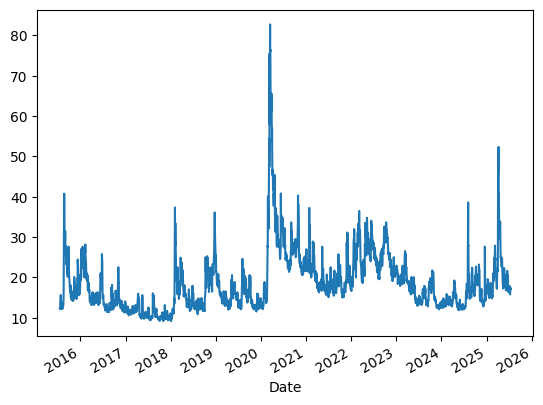

In [207]:
vix['Close']['^VIX'].plot();

In [209]:
df_vix = vix[['High']]

In [210]:
df_vix.columns = ['^VIX']

In [211]:
ifp['title']

'What will be the maximum intraday value of the VIX over the following biweekly periods in Q3, 2025? (July 21 - Aug 1)'

In [212]:
today = str(datetime.now())[0:10]
today

'2025-07-16'

In [213]:
future_start = '2025-07-21'
future_end = '2025-08-01'

In [214]:
cdf_vix = conditional_future_vix_max_cdf(
    df_vix,             # DataFrame with Date index & column '^VIX'
    today,                   # Today's date as 'YYYY-MM-DD'
    future_start,            # Start of window as 'YYYY-MM-DD'
    future_end,              # End of window as 'YYYY-MM-DD'
    band=0.5                # Conditioning band in VIX units, e.g. ±0.5
)

In [215]:
pdf_vix = cdf_to_pdf(cdf_vix)

In [216]:
percentiles = np.arange(0,100.5,0.5)

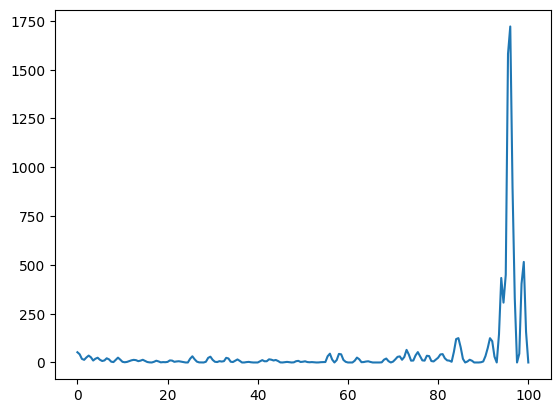

In [217]:
plt.plot(percentiles, pdf_vix);

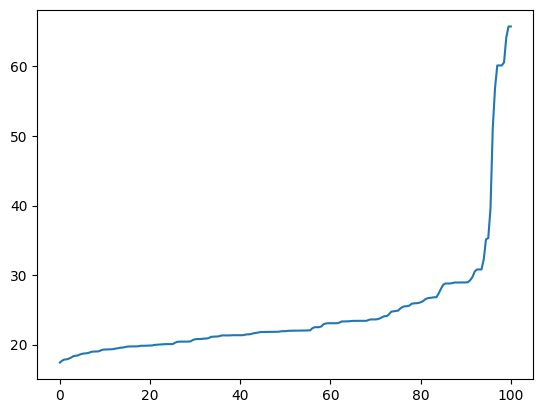

In [218]:
%matplotlib inline
import matplotlib.pylab as plt
plt.plot(percentiles, cdf_vix);

In [137]:
def conditional_future_vix_max_cdf(
    vix_high_df,             # DataFrame with Date index & column '^VIX'
    today,                   # Today's date as 'YYYY-MM-DD'
    future_start,            # Start of window as 'YYYY-MM-DD'
    future_end,              # End of window as 'YYYY-MM-DD'
    band=0.5                 # Conditioning band in VIX units, e.g. ±0.5
):

Timestamp('2025-07-16 18:56:46.714151')